In [ ]:
# Step 0: Install dependencies
!pip install -q transformers datasets torch evaluate accelerate scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

pd.set_option("display.max_rows", 100)

In [ ]:
# Loading Original Split + Pseudo-Labels

In [ ]:
# 1) Load the original frozen split and pseudo-label files
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/apt_extraction"
SPLIT_DIR = os.path.join(DRIVE_DIR, "exp_split")

os.makedirs(SPLIT_DIR, exist_ok=True)

PSEUDO_FILES = {
    "attack": os.path.join(DRIVE_DIR, "verified_pseudo_labels.json"),
    "cosine": os.path.join(DRIVE_DIR, "verified_pseudo_labels_cosine.json"),
}

# Load the original frozen split from the baseline notebook
train_df = pd.read_json(os.path.join(SPLIT_DIR, "train_df.json"))
valid_df = pd.read_json(os.path.join(SPLIT_DIR, "valid_df.json"))
test_df = pd.read_json(os.path.join(SPLIT_DIR, "test_df.json"))

with open(os.path.join(SPLIT_DIR, "label_classes.json"), "r") as f:
    label_classes = json.load(f)

label_to_idx = {label: i for i, label in enumerate(label_classes)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

print(f"Loaded split: train={len(train_df)} valid={len(valid_df)} test={len(test_df)}")
print(f"Label classes: {len(label_classes)}")
print(label_classes)

# Load pseudo-label sets from Drive
pseudo_sets = {}

for name, path in PSEUDO_FILES.items():
    if os.path.exists(path):
        df = pd.read_json(path)
        pseudo_sets[name] = df
        print(f"Loaded {name}: {len(df)} rows")
    else:
        print(f"Missing {name}: {path}")

if not pseudo_sets:
    raise FileNotFoundError("No pseudo-label files were found. Upload them to Drive first.")

Mounted at /content/drive
Loaded split: train=766 valid=163 test=166
Label classes: 25
['attributed-to', 'authored-by', 'based-on', 'beacons-to', 'communicates-with', 'compromises', 'consists-of', 'controls', 'delivers', 'downloads', 'drops', 'duplicate-of', 'exfiltrates-to', 'exploits', 'has', 'hosts', 'impersonates', 'indicates', 'located-at', 'originates-from', 'owns', 'related-to', 'targets', 'uses', 'variant-of']
Loaded attack: 386 rows
Loaded cosine: 377 rows


In [ ]:
# Schema Cleaning

In [ ]:
# Cleaning each pseudo-label set to match the original labelled schema
def clean_pseudo_df(df, label_to_idx):
    df = df.copy()

    required_cols = ["marked_text", "head_type", "tail_type", "relation"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}' in pseudo-label data.")

    df = df[required_cols].dropna().copy()
    df = df[df["relation"].isin(label_to_idx)].copy()
    df["label"] = df["relation"].map(label_to_idx)

    return df.reset_index(drop=True)

for name, df in list(pseudo_sets.items()):
    pseudo_sets[name] = clean_pseudo_df(df, label_to_idx)
    print(f"{name}: kept {len(pseudo_sets[name])} rows after schema filtering")

attack: kept 386 rows after schema filtering
cosine: kept 377 rows after schema filtering


In [ ]:
# Exploratory Analysis & Plots


=== attack ===
Rows: 386
Unique relations: 24
Head types:
head_type
threat-actor      120
malware            87
FILEPATH           60
tools              43
IPV4               18
identity           13
Infrastucture      12
url                12
hash                6
SOFTWARE            4
attack-pattern      4
campaign            4
EMAIL               2
REGISTRYKEY         1
Tail types:
tail_type
identity          55
FILEPATH          37
malware           35
tools             34
SOFTWARE          34
attack-pattern    34
Infrastucture     32
url               28
hash              21
vulnerability     20
location          17
threat-actor      15
IPV4              11
EMAIL              8
campaign           3
TIME               1
REGISTRYKEY        1

=== cosine ===
Rows: 377
Unique relations: 24
Head types:
head_type
threat-actor      118
malware            82
FILEPATH           59
tools              43
IPV4               18
identity           13
Infrastucture      12
url                12

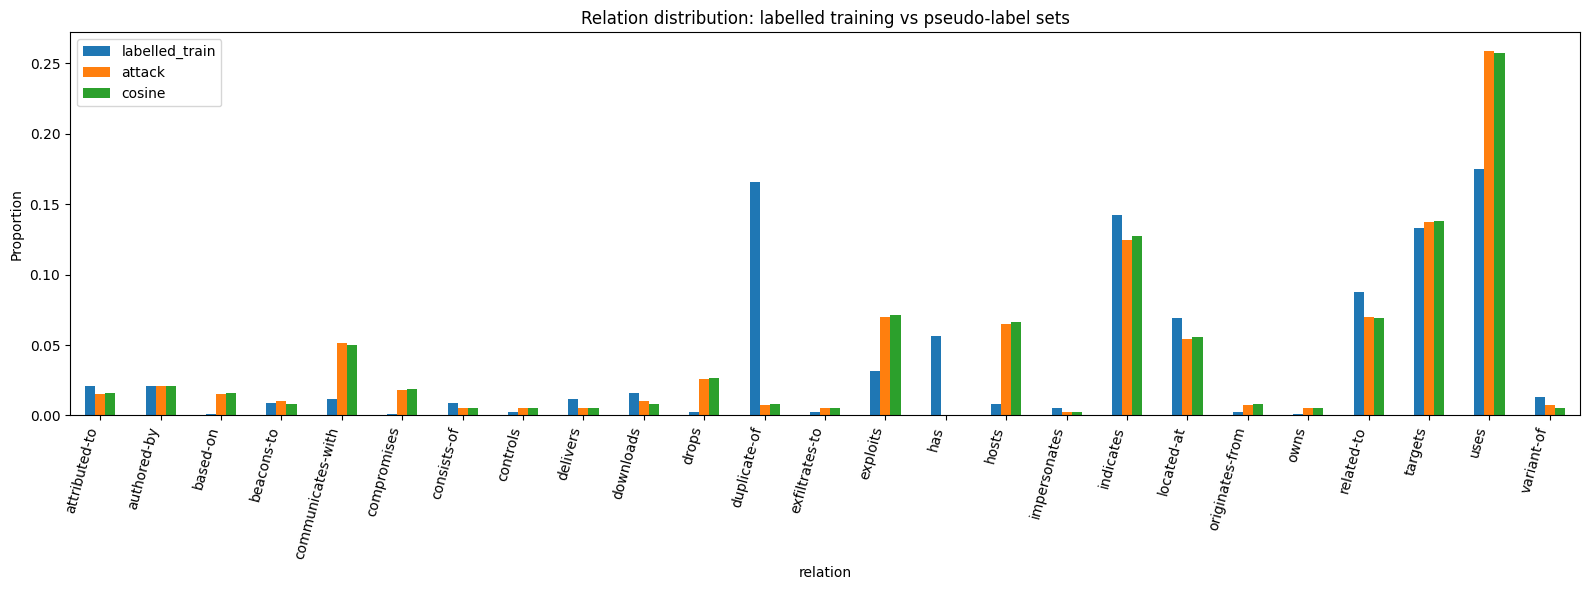

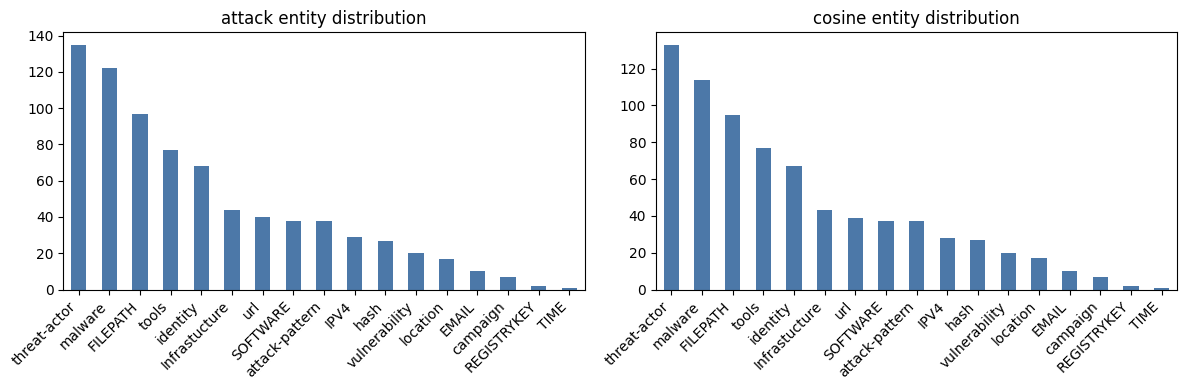


attack: unseen relation labels relative to original training split = []

cosine: unseen relation labels relative to original training split = []


In [ ]:
# Basic analysis of the pseudo-label sets and the labelled training data
for name, df in pseudo_sets.items():
    print(f"\n=== {name} ===")
    print(f"Rows: {len(df)}")
    print(f"Unique relations: {df['relation'].nunique()}")
    print(f"Head types:\n{df['head_type'].value_counts().to_string()}")
    print(f"Tail types:\n{df['tail_type'].value_counts().to_string()}")

# Compare relation distribution: original labelled training vs pseudo-label sets
labelled_rel = train_df["relation"].value_counts(normalize=True)
attack_rel = pseudo_sets["attack"]["relation"].value_counts(normalize=True)
cosine_rel = pseudo_sets["cosine"]["relation"].value_counts(normalize=True)

relation_compare = pd.DataFrame({
    "labelled_train": labelled_rel,
    "attack": attack_rel,
    "cosine": cosine_rel
}).fillna(0.0)

print("\nRelation distribution comparison:")
print(relation_compare.round(3).to_string())

relation_compare.plot(kind="bar", figsize=(16, 6))
plt.title("Relation distribution: labelled training vs pseudo-label sets")
plt.ylabel("Proportion")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# Comparing entity type distribution (head + tail)
plt.figure(figsize=(12, 4))
for i, (name, df) in enumerate(pseudo_sets.items(), start=1):
    plt.subplot(1, len(pseudo_sets), i)
    entity_counts = pd.concat([df["head_type"], df["tail_type"]], ignore_index=True).value_counts()
    entity_counts.plot(kind="bar", color="#4C78A8")
    plt.title(f"{name} entity distribution")
    plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Counting overlap between pseudo-label relation vocabulary and labelled relation vocabulary
for name, df in pseudo_sets.items():
    unseen = sorted(set(df["relation"]) - set(train_df["relation"]))
    print(f"\n{name}: unseen relation labels relative to original training split = {unseen}")

In [ ]:
# Preparing Candidate Training Sets

In [ ]:
# Building candidate training sets using the original split
candidate_train_sets = {
    "baseline": train_df.copy()
}

for name, pseudo_df in pseudo_sets.items():
    merged = pd.concat(
        [
            train_df[["marked_text", "head_type", "tail_type", "relation", "label"]],
            pseudo_df[["marked_text", "head_type", "tail_type", "relation", "label"]],
        ],
        ignore_index=True
    )
    candidate_train_sets[name] = merged
    print(f"{name}: merged train size = {len(merged)}")

attack: merged train size = 1152
cosine: merged train size = 1143


In [ ]:
# Defining Trainer & Helper Functions

In [ ]:
# Define training and helper functions
MODELS = {
    "BERT": "bert-base-uncased",
    "SecureBERT": "ehsanaghaei/SecureBERT",
}

MAX_LENGTH = 160

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

def make_hf_dataset(df, tokenizer):
    ds = Dataset.from_pandas(df[["marked_text", "label"]])
    ds = ds.map(
        lambda batch: tokenizer(batch["marked_text"], truncation=True, max_length=MAX_LENGTH),
        batched=True
    )
    ds = ds.rename_column("label", "labels")
    return ds.remove_columns(["marked_text"])

def train_and_evaluate(model_key, model_path, candidate_name, train_data, eval_data):
    print(f"\n{'=' * 60}")
    print(f"Training {model_key} on '{candidate_name}'")
    print(f"{'=' * 60}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.add_special_tokens({"additional_special_tokens": ["[E1]", "[/E1]", "[E2]", "[/E2]"]})

    train_ds = make_hf_dataset(train_data, tokenizer)
    eval_ds = make_hf_dataset(eval_data, tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=len(label_classes))
    model.resize_token_embeddings(len(tokenizer))

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(label_classes)),
        y=train_data["label"].to_numpy()
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float)

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss

    output_dir = f"./{model_key.lower()}_{candidate_name}_results"

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=4,        # Reduced batch size for GPU memory
        gradient_accumulation_steps=2,        # Keeps effective batch size = 8
        per_device_eval_batch_size=8,
        eval_accumulation_steps=10,           # Offloads eval to CPU to prevent GPU RAM overflow
        label_smoothing_factor=0.1,
        num_train_epochs=30,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=20,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        fp16=torch.cuda.is_available(),
        report_to="none",
        save_total_limit=1,                   # Keeps only 1 checkpoint to save disk space
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

    trainer.train()
    metrics = trainer.evaluate(eval_ds)

    del model
    torch.cuda.empty_cache()

    return trainer, tokenizer, metrics

In [ ]:
# Executing Training Loop & Pick Validation Winners

In [ ]:
# Run Training Loops
validation_results = []
trained_models = {}

for model_key, model_path in MODELS.items():
    for candidate_name, train_data in candidate_train_sets.items():
        trainer, tokenizer, metrics = train_and_evaluate(
            model_key=model_key,
            model_path=model_path,
            candidate_name=candidate_name,
            train_data=train_data,
            eval_data=valid_df
        )

        trained_models[(model_key, candidate_name)] = (trainer, tokenizer)

        validation_results.append({
            "model": model_key,
            "candidate": candidate_name,
            "train_size": len(train_data),
            "val_accuracy": metrics["eval_accuracy"],
            "val_macro_f1": metrics["eval_macro_f1"],
            "val_weighted_f1": metrics["eval_weighted_f1"],
        })

validation_df_summary = pd.DataFrame(validation_results)
print("\n=== Validation Comparison ===")
print(validation_df_summary.to_string(index=False))

# Pick the winner per model based on validation macro F1
winners = validation_df_summary.loc[
    validation_df_summary.groupby("model")["val_macro_f1"].idxmax()
].copy()

print("\nWinner per model (validation):")
print(winners.to_string(index=False))


Training BERT on 'baseline'


Map:   0%|          | 0/766 [00:00<?, ? examples/s]

Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.108393,1.236299,19,0.754601,0.646391,0.714537,0.663417,0.752185,0.754601,0.746982



=== Validation Comparison ===
     model candidate  train_size  val_accuracy  val_macro_f1  val_weighted_f1
      BERT  baseline         766      0.699387      0.555432         0.685973
      BERT    attack        1152      0.699387      0.518195         0.694973
      BERT    cosine        1143      0.705521      0.549280         0.697993
SecureBERT  baseline         766      0.748466      0.595308         0.746726
SecureBERT    attack        1152      0.803681      0.751468         0.803099
SecureBERT    cosine        1143      0.754601      0.663417         0.746982

Winner per model (validation):
     model candidate  train_size  val_accuracy  val_macro_f1  val_weighted_f1
      BERT  baseline         766      0.699387      0.555432         0.685973
SecureBERT    attack        1152      0.803681      0.751468         0.803099


In [ ]:
# Evaluating Models on Test Set

In [ ]:
# Final test evaluation
final_results = []

for _, row in winners.iterrows():
    model_key = row["model"]
    candidate_name = row["candidate"]

    trainer, tokenizer = trained_models[(model_key, candidate_name)]

    def make_test_dataset(df):
        ds = Dataset.from_pandas(df[["marked_text", "label"]])
        ds = ds.map(
            lambda batch: tokenizer(batch["marked_text"], truncation=True, max_length=MAX_LENGTH),
            batched=True
        )
        ds = ds.rename_column("label", "labels")
        return ds.remove_columns(["marked_text"])

    test_ds = make_test_dataset(test_df)
    test_metrics = trainer.evaluate(test_ds)

    preds_output = trainer.predict(test_ds)
    preds = np.argmax(preds_output.predictions, axis=-1)
    labels = preds_output.label_ids

    present_labels = np.unique(labels)
    present_names = [idx_to_label[int(i)] for i in present_labels]

    print(f"\n[{model_key}] winner candidate: {candidate_name}")
    print(test_metrics)

    print(classification_report(
        labels,
        preds,
        labels=present_labels,
        target_names=present_names,
        zero_division=0
    ))

    save_dir = f"./winner_{model_key.lower()}_{candidate_name}"
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"Saved winner model to {save_dir}")

    final_results.append({
        "model": model_key,
        "winner_candidate": candidate_name,
        "test_accuracy": test_metrics["eval_accuracy"],
        "test_macro_f1": test_metrics["eval_macro_f1"],
        "test_weighted_f1": test_metrics["eval_weighted_f1"],
    })

final_results_df = pd.DataFrame(final_results)
print("\n=== Final test results ===")
print(final_results_df.to_string(index=False))

Map:   0%|          | 0/166 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.361317,1.562440,15,0.716867,0.501900,0.489642,0.484008,0.710741,0.716867,0.699986



[BERT] winner candidate: baseline
{'eval_loss': 1.562440037727356, 'eval_accuracy': 0.7168674698795181, 'eval_macro_precision': 0.5019004011861155, 'eval_macro_recall': 0.4896419231805111, 'eval_macro_f1': 0.4840081967045797, 'eval_weighted_precision': 0.7107413169160156, 'eval_weighted_recall': 0.7168674698795181, 'eval_weighted_f1': 0.6999858408418479}
                   precision    recall  f1-score   support

    attributed-to       1.00      0.75      0.86         4
      authored-by       1.00      0.50      0.67         4
       beacons-to       0.00      0.00      0.00         1
communicates-with       0.67      1.00      0.80         2
      consists-of       0.00      0.00      0.00         1
         delivers       0.50      0.50      0.50         2
        downloads       0.50      0.50      0.50         2
            drops       0.00      0.00      0.00         1
     duplicate-of       0.76      0.70      0.73        27
   exfiltrates-to       0.00      0.00      0.00   

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved winner model to ./winner_bert_baseline


Map:   0%|          | 0/166 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.030645,1.514888,21,0.765060,0.516860,0.555580,0.524691,0.767768,0.765060,0.759854



[SecureBERT] winner candidate: attack
{'eval_loss': 1.5148881673812866, 'eval_accuracy': 0.7650602409638554, 'eval_macro_precision': 0.516859649842843, 'eval_macro_recall': 0.5555803164177548, 'eval_macro_f1': 0.5246905706175834, 'eval_weighted_precision': 0.7677676229589765, 'eval_weighted_recall': 0.7650602409638554, 'eval_weighted_f1': 0.7598540563735362}
                   precision    recall  f1-score   support

    attributed-to       1.00      0.75      0.86         4
      authored-by       0.40      0.50      0.44         4
       beacons-to       0.00      0.00      0.00         1
communicates-with       0.50      1.00      0.67         2
      consists-of       0.00      0.00      0.00         1
         delivers       0.50      0.50      0.50         2
        downloads       0.50      0.50      0.50         2
            drops       0.50      1.00      0.67         1
     duplicate-of       0.75      0.78      0.76        27
   exfiltrates-to       0.00      0.00      0.0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved winner model to ./winner_securebert_attack

=== Final test results ===
     model winner_candidate  test_accuracy  test_macro_f1  test_weighted_f1
      BERT         baseline       0.716867       0.484008          0.699986
SecureBERT           attack       0.765060       0.524691          0.759854
